## Introduction

Rusty Bargain used car sales service is developing an app to attract new customers. In that app, you can quickly find out the market value of your car. You have access to historical data: technical specifications, trim versions, and prices. You need to build the model to determine the value. 

Rusty Bargain is interested in:

- the quality of the prediction;
- the speed of the prediction;
- the time required for training

## Importing necessary libraries

In [1]:
import numpy as np
import pandas as pd
import time as time
import seaborn as sns
import matplotlib.pyplot as plt

import sklearn.linear_model
import sklearn.metrics
import sklearn.neighbors
import sklearn.preprocessing
import gc
import math
import lightgbm as lgb
import sklearn


from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier,DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from xgboost import XGBRegressor



## Data preparation

In [2]:
df = pd.read_csv('datasets/car_data.csv')

In [3]:
display (df)
display (df.info())

,DateCrawled,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Mileage,RegistrationMonth,FuelType,Brand,NotRepaired,DateCreated,NumberOfPictures,PostalCode,LastSeen
0,24/03/2016 11:52,480,NaN,1993,manual,0,golf,150000,0,petrol,volkswagen,NaN,24/03/2016 00:00,0,70435,07/04/2016 03:16
1,24/03/2016 10:58,18300,coupe,2011,manual,190,NaN,125000,5,gasoline,audi,yes,24/03/2016 00:00,0,66954,07/04/2016 01:46
2,14/03/2016 12:52,9800,suv,2004,auto,163,grand,125000,8,gasoline,jeep,NaN,14/03/2016 00:00,0,90480,05/04/2016 12:47
3,17/03/2016 16:54,1500,small,2001,manual,75,golf,150000,6,petrol,volkswagen,no,17/03/2016 00:00,0,91074,17/03/2016 17:40
4,31/03/2016 17:25,3600,small,2008,manual,69,fabia,90000,7,gasoline,skoda,no,31/03/2016 00:00,0,60437,06/04/2016 10:17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
354364,21/03/2016 09:50,0,NaN,2005,manual,0,colt,150000,7,petrol,mitsubishi,yes,21/03/2016 00:00,0,2694,21/03/2016 10:42
354365,14/03/2016 17:48,2200,NaN,2005,NaN,0,NaN,20000,1,NaN,sonstige_autos,NaN,14/03/2016 00:00,0,39576,06/04/2016 00:46
354366,05/03/2016 19:56,1199,convertible,2000,auto,101,fortwo,125000,3,petrol,smart,no,05/03/2016 00:00,0,26135,11/03/2016 18:17
354367,19/03/2016 18:57,9200,bus,1996,manual,102,transporter,150000,3,gasoline,volkswagen,no,19/03/2016 00:00,0,87439,07/04/2016 07:15


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354369 entries, 0 to 354368
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   DateCrawled        354369 non-null  object
 1   Price              354369 non-null  int64 
 2   VehicleType        316879 non-null  object
 3   RegistrationYear   354369 non-null  int64 
 4   Gearbox            334536 non-null  object
 5   Power              354369 non-null  int64 
 6   Model              334664 non-null  object
 7   Mileage            354369 non-null  int64 
 8   RegistrationMonth  354369 non-null  int64 
 9   FuelType           321474 non-null  object
 10  Brand              354369 non-null  object
 11  NotRepaired        283215 non-null  object
 12  DateCreated        354369 non-null  object
 13  NumberOfPictures   354369 non-null  int64 
 14  PostalCode         354369 non-null  int64 
 15  LastSeen           354369 non-null  object
dtypes: int64(7), object(

None

In [4]:
# Renaming columns for consistency
df.columns = df.columns.str.lower()
display(df)

,datecrawled,price,vehicletype,registrationyear,gearbox,power,model,mileage,registrationmonth,fueltype,brand,notrepaired,datecreated,numberofpictures,postalcode,lastseen
0,24/03/2016 11:52,480,NaN,1993,manual,0,golf,150000,0,petrol,volkswagen,NaN,24/03/2016 00:00,0,70435,07/04/2016 03:16
1,24/03/2016 10:58,18300,coupe,2011,manual,190,NaN,125000,5,gasoline,audi,yes,24/03/2016 00:00,0,66954,07/04/2016 01:46
2,14/03/2016 12:52,9800,suv,2004,auto,163,grand,125000,8,gasoline,jeep,NaN,14/03/2016 00:00,0,90480,05/04/2016 12:47
3,17/03/2016 16:54,1500,small,2001,manual,75,golf,150000,6,petrol,volkswagen,no,17/03/2016 00:00,0,91074,17/03/2016 17:40
4,31/03/2016 17:25,3600,small,2008,manual,69,fabia,90000,7,gasoline,skoda,no,31/03/2016 00:00,0,60437,06/04/2016 10:17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
354364,21/03/2016 09:50,0,NaN,2005,manual,0,colt,150000,7,petrol,mitsubishi,yes,21/03/2016 00:00,0,2694,21/03/2016 10:42
354365,14/03/2016 17:48,2200,NaN,2005,NaN,0,NaN,20000,1,NaN,sonstige_autos,NaN,14/03/2016 00:00,0,39576,06/04/2016 00:46
354366,05/03/2016 19:56,1199,convertible,2000,auto,101,fortwo,125000,3,petrol,smart,no,05/03/2016 00:00,0,26135,11/03/2016 18:17
354367,19/03/2016 18:57,9200,bus,1996,manual,102,transporter,150000,3,gasoline,volkswagen,no,19/03/2016 00:00,0,87439,07/04/2016 07:15


In [5]:
# Checking for null values.
df.isnull().sum()

datecrawled              0
price                    0
vehicletype          37490
registrationyear         0
gearbox              19833
power                    0
model                19705
mileage                  0
registrationmonth        0
fueltype             32895
brand                    0
notrepaired          71154
datecreated              0
numberofpictures         0
postalcode               0
lastseen                 0
dtype: int64

Since I'm not sure about the data loss for vehicletype, gearbox, model, fueltype, and notrepaired. I will replace the values with 'unknown' for now. I will come back and drop those values if necessary for the data analysis.

In [6]:
null_columns = ['vehicletype', 'gearbox', 'model', 'fueltype', 'notrepaired']
df[null_columns] = df[null_columns].fillna('unknown')
df.isnull().sum()

datecrawled          0
price                0
vehicletype          0
registrationyear     0
gearbox              0
power                0
model                0
mileage              0
registrationmonth    0
fueltype             0
brand                0
notrepaired          0
datecreated          0
numberofpictures     0
postalcode           0
lastseen             0
dtype: int64

In [7]:
# Checking for outliers
numeric_df = df.select_dtypes(include=['number'])
Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3-Q1
outliers = (numeric_df < (Q1 - 1.5 * IQR)) | (numeric_df> (Q3 + 1.5 *IQR))

display(outliers.sum())

price                18979
registrationyear      6309
power                 7340
mileage              53257
registrationmonth        0
numberofpictures         0
postalcode               0
dtype: int64

There are some outliers in our data. I will investigate further.

In [8]:
print(df.describe())

               price  registrationyear          power        mileage  \
count  354369.000000     354369.000000  354369.000000  354369.000000   
mean     4416.656776       2004.234448     110.094337  128211.172535   
std      4514.158514         90.227958     189.850405   37905.341530   
min         0.000000       1000.000000       0.000000    5000.000000   
25%      1050.000000       1999.000000      69.000000  125000.000000   
50%      2700.000000       2003.000000     105.000000  150000.000000   
75%      6400.000000       2008.000000     143.000000  150000.000000   
max     20000.000000       9999.000000   20000.000000  150000.000000   

       registrationmonth  numberofpictures     postalcode  
count      354369.000000          354369.0  354369.000000  
mean            5.714645               0.0   50508.689087  
std             3.726421               0.0   25783.096248  
min             0.000000               0.0    1067.000000  
25%             3.000000               0.0   30165.

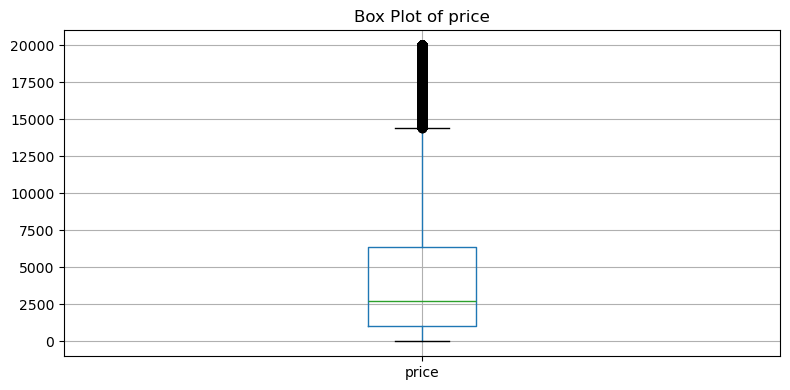

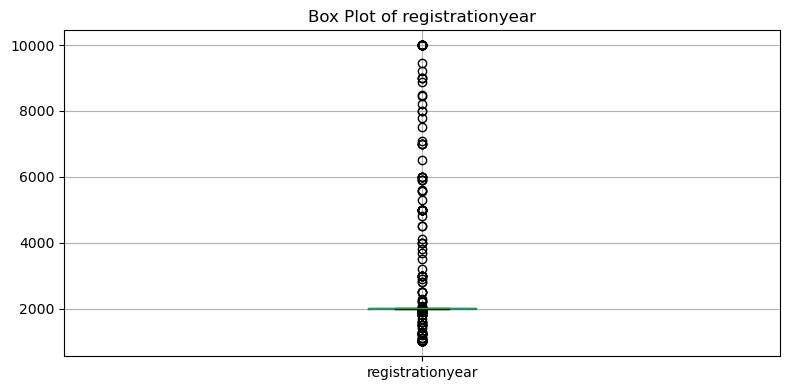

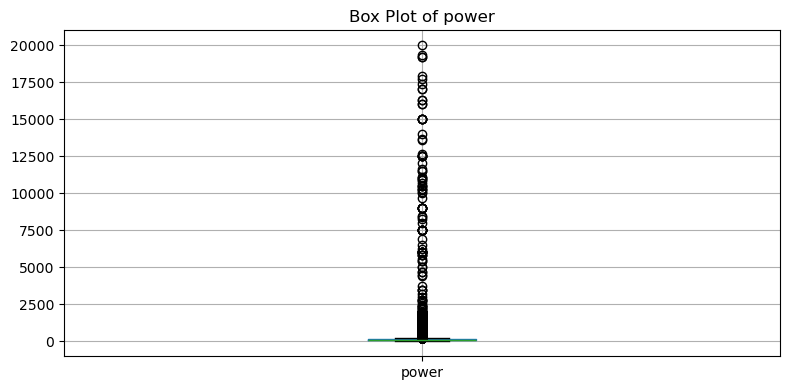

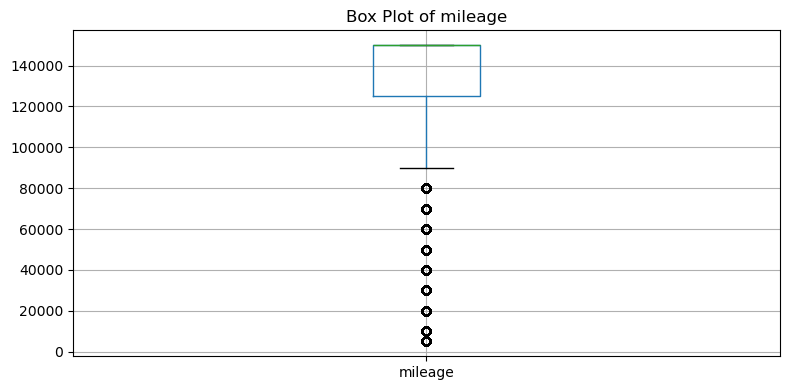

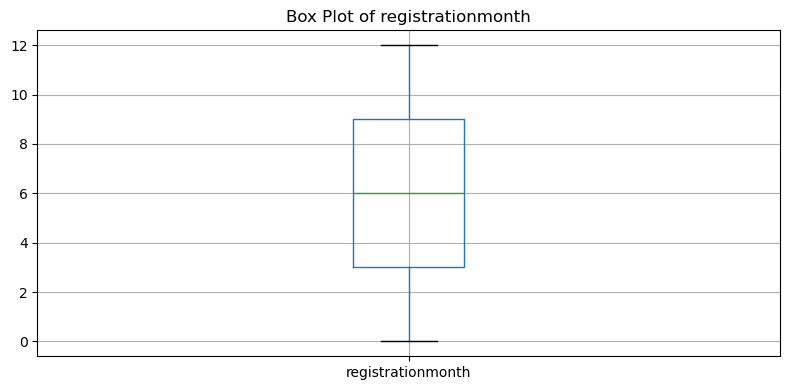

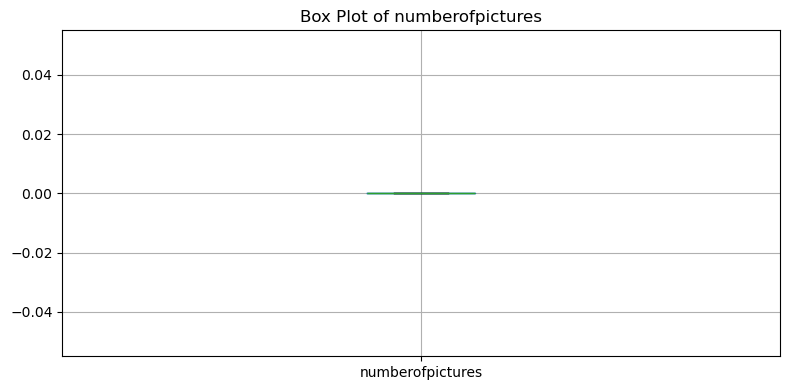

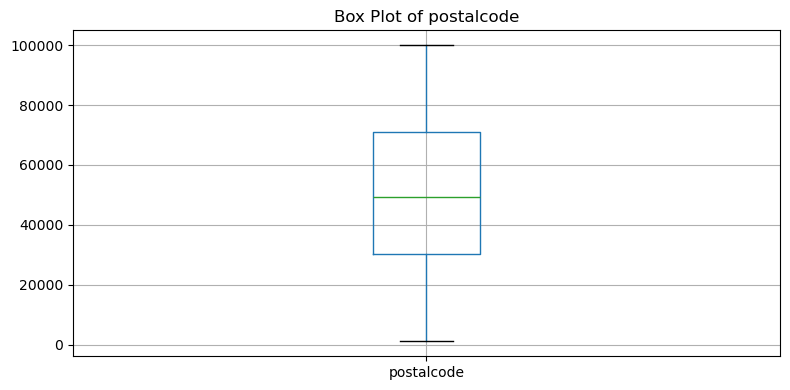

In [9]:
for column in df.select_dtypes(include='number').columns:
    plt.figure(figsize=(8, 4))
    df.boxplot(column=column)
    plt.title(f'Box Plot of {column}')
    plt.grid(True)
    plt.tight_layout()
    plt.show()


So we see a few peculiar patterns here.

Price, registration year and power have outliers that don't make any sense. Price has a few that are 0 and locked in at 20000. Year column has 1000 and 9999. and power goes all the way to 20000 which is a rocket. Mileage has outliers on the low end which makes sense due to some cars not being driven as much. We will need to remove the outliers from the first 3.

In [10]:
def remove_outliers_iqr(df, columns):
    df_cleaned = df.copy()
    for column in columns:
        Q1 = df_cleaned[column].quantile(0.25)
        Q3 = df_cleaned[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df_cleaned = df_cleaned[(df_cleaned[column] >= lower_bound) & (df_cleaned[column] <= upper_bound)]
    return df_cleaned

df_cleaned = remove_outliers_iqr(df, ['price', 'registrationyear','power'])

In [11]:
print(df_cleaned.describe())

               price  registrationyear          power        mileage  \
count  323437.000000     323437.000000  323437.000000  323437.000000   
mean     3630.794152       2003.275210      99.920383  130715.224294   
std      3415.549185          6.288974      54.818924   35698.965033   
min         0.000000       1987.000000       0.000000    5000.000000   
25%       999.000000       1999.000000      66.000000  125000.000000   
50%      2450.000000       2003.000000     101.000000  150000.000000   
75%      5400.000000       2007.000000     140.000000  150000.000000   
max     14400.000000       2019.000000     248.000000  150000.000000   

       registrationmonth  numberofpictures     postalcode  
count      323437.000000          323437.0  323437.000000  
mean            5.704493               0.0   50274.635379  
std             3.736234               0.0   25729.696300  
min             0.000000               0.0    1067.000000  
25%             3.000000               0.0   29633.

In [12]:
# Removing additional column specific outliers
df_cleaned = df_cleaned[
    (df_cleaned['power'] >= 50) &
    (df_cleaned['price'] >= 300)  
    ]
print(df.describe())

               price  registrationyear          power        mileage  \
count  354369.000000     354369.000000  354369.000000  354369.000000   
mean     4416.656776       2004.234448     110.094337  128211.172535   
std      4514.158514         90.227958     189.850405   37905.341530   
min         0.000000       1000.000000       0.000000    5000.000000   
25%      1050.000000       1999.000000      69.000000  125000.000000   
50%      2700.000000       2003.000000     105.000000  150000.000000   
75%      6400.000000       2008.000000     143.000000  150000.000000   
max     20000.000000       9999.000000   20000.000000  150000.000000   

       registrationmonth  numberofpictures     postalcode  
count      354369.000000          354369.0  354369.000000  
mean            5.714645               0.0   50508.689087  
std             3.726421               0.0   25783.096248  
min             0.000000               0.0    1067.000000  
25%             3.000000               0.0   30165.

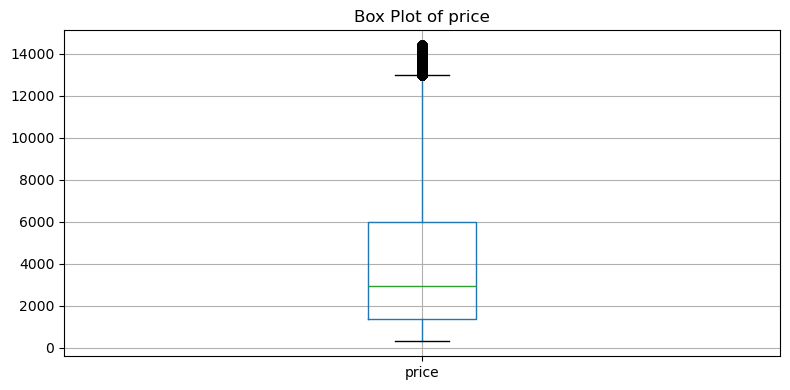

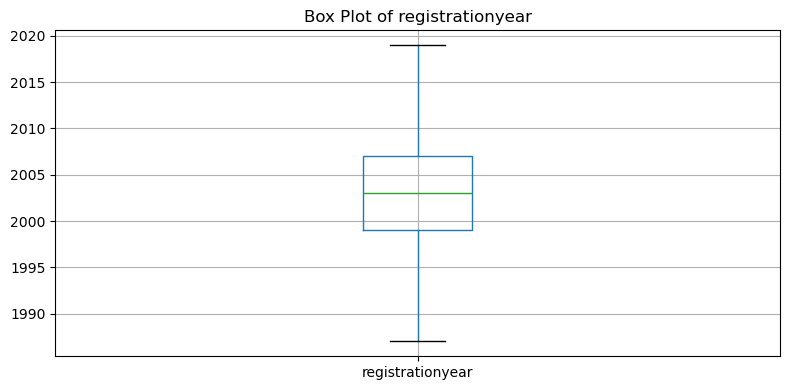

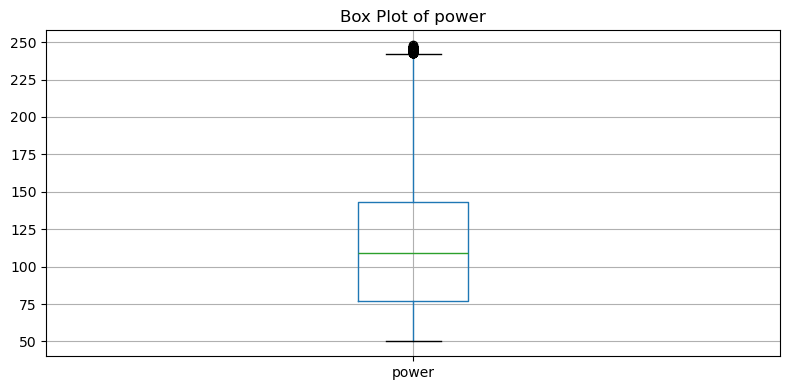

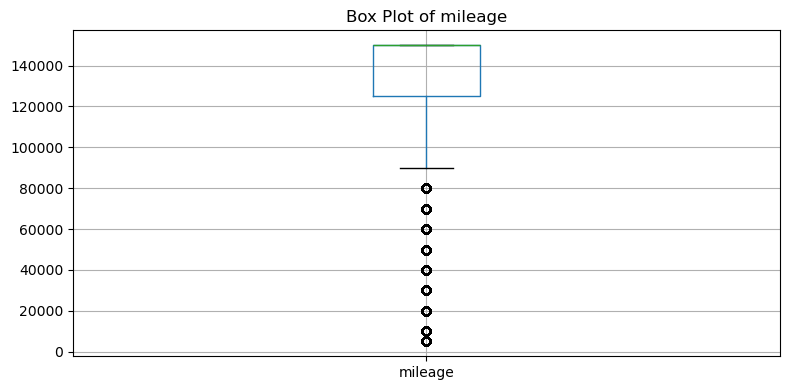

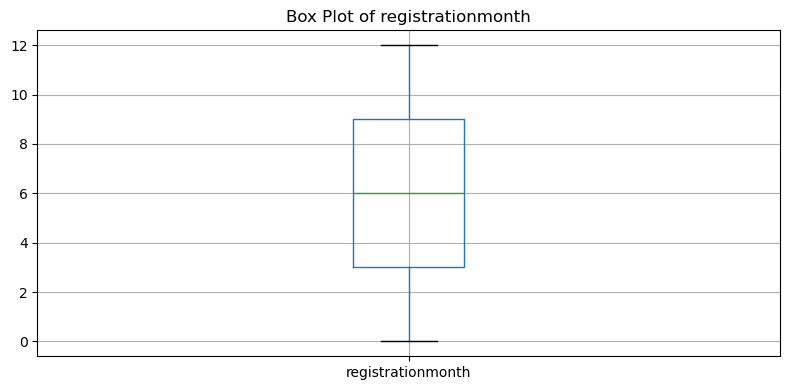

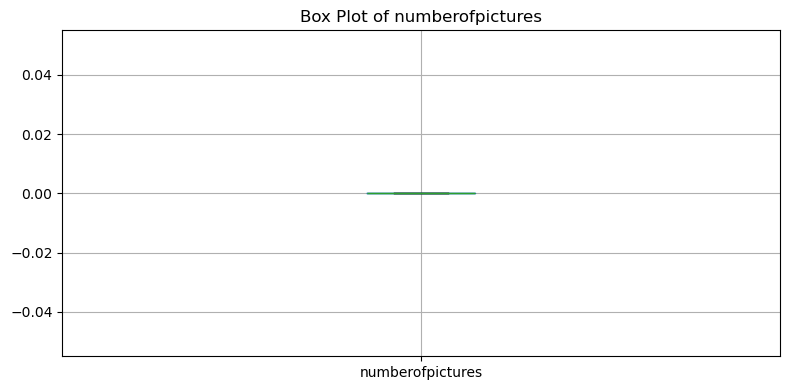

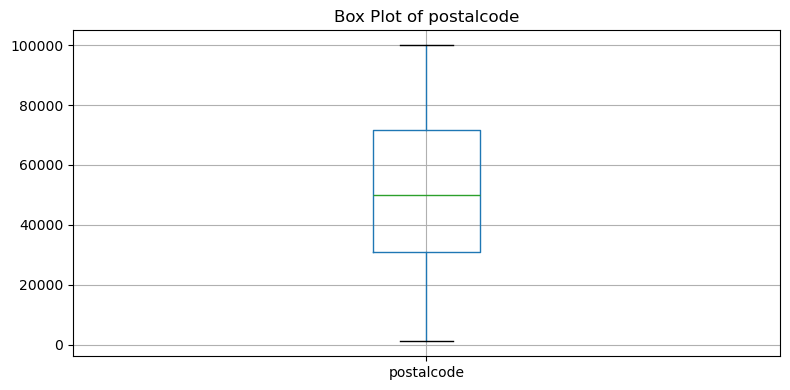

In [13]:
for column in df_cleaned.select_dtypes(include='number').columns:
    plt.figure(figsize=(8, 4))
    df_cleaned.boxplot(column=column)
    plt.title(f'Box Plot of {column}')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

These data sets now look much more reasonable.

In [14]:
# dropping datecrawled and datecreated. Converting lastseen to usable datetime.
df_cleaned['lastseen'] = df_cleaned['lastseen'].apply(pd.to_datetime)

df_cleaned['lsyear'] = df_cleaned['lastseen'].dt.year
df_cleaned['lsmonth'] = df_cleaned['lastseen'].dt.month
df_cleaned['lsday'] = df_cleaned['lastseen'].dt.day
df_cleaned['lsdayofweek'] = df_cleaned['lastseen'].dt.dayofweek
display(df_cleaned.info())

df_cleaned = df_cleaned.drop(['datecrawled','datecreated','lastseen'], axis=1)

C:\Users\mytho\AppData\Local\Temp\ipykernel_124272\3605594687.py:2: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_cleaned['lastseen'] = df_cleaned['lastseen'].apply(pd.to_datetime)


<class 'pandas.core.frame.DataFrame'>
Index: 267335 entries, 2 to 354368
Data columns (total 20 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   datecrawled        267335 non-null  object        
 1   price              267335 non-null  int64         
 2   vehicletype        267335 non-null  object        
 3   registrationyear   267335 non-null  int64         
 4   gearbox            267335 non-null  object        
 5   power              267335 non-null  int64         
 6   model              267335 non-null  object        
 7   mileage            267335 non-null  int64         
 8   registrationmonth  267335 non-null  int64         
 9   fueltype           267335 non-null  object        
 10  brand              267335 non-null  object        
 11  notrepaired        267335 non-null  object        
 12  datecreated        267335 non-null  object        
 13  numberofpictures   267335 non-null  int64        

None

In [15]:
# Checking for dupes
duplicates = df_cleaned[df_cleaned.duplicated()]
print(duplicates)
df_cleaned.drop_duplicates(inplace=True)
duplicates = df_cleaned[df_cleaned.duplicated()]
print(duplicates)

        price  vehicletype  registrationyear gearbox  power     model  \
4300     1250        wagon              2000  manual    131    mondeo   
4604     7000          suv              2006  manual    177       rav   
4826     5500        sedan              2000  manual    170       3er   
6972     1699  convertible              1996    auto    101      golf   
9413     3399        small              2002  manual     90       one   
...       ...          ...               ...     ...    ...       ...   
354217  10999        small              2011  manual    135    fiesta   
354274   7399        wagon              2006    auto     96        a4   
354300   8940        sedan              2009  manual     80      golf   
354317   5990        small              2009  manual     86     ibiza   
354352   6500        sedan              2003    auto    145  e_klasse   

        mileage  registrationmonth  fueltype          brand notrepaired  \
4300     150000                  7    petrol    

## Model training

In [16]:
# Setting up target and features.
features = df_cleaned.drop(columns=['price'])
target = df_cleaned['price']

# Splitting the data set into training, validation, and test sets.
features_train, features_valid, target_train, target_valid = train_test_split(features, target, test_size=0.40, random_state=12345)
features_valid, features_test, target_valid, target_test = train_test_split(features, target, test_size=0.50, random_state=12345)

# Encoding Columns that need encoding.
# Defing the columns that need encoding
categorical_cols = ['vehicletype', 'gearbox', 'model','fueltype','brand','notrepaired']

# Create the transformer
preprocessor = column_transformer = ColumnTransformer(transformers=[
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ],
    remainder='passthrough')

# Create pipeline with Decision Tree Classifier
dt_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('regressor', DecisionTreeRegressor(random_state=12345))
])


# Optimizing Decision Tree
dt_param_grid = {
    'regressor__max_depth': [3, 5, 10, None],
    'regressor__min_samples_split': [2, 5, 10],
    'regressor__min_samples_leaf': [1, 2, 4],
    'regressor__max_features': [None, 'sqrt', 'log2'],
    'regressor__criterion': ['squared_error']
}
start_time = time.time()

# Define the reusable evaluation function
def evaluate_model(pipeline, param_grid, model_name, cv, njobs, n_iter):
    start_time = time.time()
    grid = RandomizedSearchCV(
        pipeline,
        param_grid,
        scoring='neg_root_mean_squared_error',
        cv=cv,
        n_jobs=njobs,
        n_iter=n_iter
    )
    grid.fit(features_train, target_train)
    rmse = -grid.best_score_
    end_time = time.time()

    print(f"{model_name} Best RMSE: {rmse:.2f}")
    print(f"{model_name} Best Parameters: {grid.best_params_}")
    print(f"{model_name} Execution Time: {end_time - start_time:.2f} seconds\n")
    model = grid.best_estimator_

    fit_start = time.time()
    model.fit(features_train, target_train)
    fit_end = time.time()

    pred_start = time.time()
    valid_predictions = model.predict(features_valid)
    pred_end = time.time()

    valid_rmse = np.sqrt(mean_squared_error(target_valid, valid_predictions))
    print(f"{model_name} Validation RMSE: {valid_rmse:.2f}")
    print(f"{model_name} Model Fit Execution Time: {fit_end - fit_start:.2f} seconds\n")
    print(f"{model_name} Modelf Prediction Execution Time: {pred_end - pred_start:.2f} seconds\n")
    return grid

# Decision Tree evaluation
evaluate_model(dt_pipeline, dt_param_grid, 'Decision Tree Regressor', 2, 1,3)
gc.collect()


Decision Tree Regressor Best RMSE: 3315.49
Decision Tree Regressor Best Parameters: {'regressor__min_samples_split': 5, 'regressor__min_samples_leaf': 1, 'regressor__max_features': 'log2', 'regressor__max_depth': 5, 'regressor__criterion': 'squared_error'}
Decision Tree Regressor Execution Time: 3.50 seconds

Decision Tree Regressor Validation RMSE: 3255.28
Decision Tree Regressor Model Fit Execution Time: 0.51 seconds

Decision Tree Regressor Modelf Prediction Execution Time: 0.34 seconds



352

In [17]:
# Random forest optimization
rf_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('regressor', RandomForestRegressor(random_state=12345))
])

rf_param_grid= {
    'regressor__n_estimators': [50,100,150],
    'regressor__max_depth': [5, 10, 15],
    'regressor__min_samples_leaf': [1,2, 4]
}

# Random forest evaluation
evaluate_model(rf_pipeline, rf_param_grid, 'Random Forest', 2, 2,3)
gc.collect()


Random Forest Best RMSE: 1384.80
Random Forest Best Parameters: {'regressor__n_estimators': 100, 'regressor__min_samples_leaf': 4, 'regressor__max_depth': 15}
Random Forest Execution Time: 577.82 seconds

Random Forest Validation RMSE: 1144.46
Random Forest Model Fit Execution Time: 219.54 seconds

Random Forest Modelf Prediction Execution Time: 1.98 seconds



158

In [18]:
# Linear Regression optimization
lr_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('regressor', LinearRegression())
])

# Fit model

fit_start = time.time()
lr_pipeline.fit(features_train,target_train)
fit_end = time.time()

# Predict on validation set
pred_start = time.time()
val_predictions = lr_pipeline.predict(features_valid)
pred_end = time.time()

# Evaluate

val_rmse = np.sqrt(mean_squared_error(target_valid, val_predictions))


print(f"Linear Regression Validation RMSE: {val_rmse:.2f}")
print(f"Fit Time: {fit_end - fit_start:.2f} seconds")
print(f"Prediction Time: {pred_end - pred_start:.2f} seconds")


gc.collect()


Linear Regression Validation RMSE: 1839.95
Fit Time: 1.98 seconds
Prediction Time: 0.29 seconds


44

In [19]:
# LightGBM 
lgbm_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('regressor', LGBMRegressor(random_state=12345))
])

lgbm_param_grid = {
    'regressor__n_estimators': [100, 200],
    'regressor__learning_rate': [0.1, 0.05],
    'regressor__max_depth': [3, 5, -1],
    'regressor__num_leaves': [31, 50]
}
# LightGBM evaluation
evaluate_model(lgbm_pipeline, lgbm_param_grid, 'LightGBM Regression', 2, 2,3)
gc.collect()


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003465 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1105
[LightGBM] [Info] Number of data points in the train set: 155481, number of used features: 283
[LightGBM] [Info] Start training from score 4080.045690
LightGBM Regression Best RMSE: 1304.98
LightGBM Regression Best Parameters: {'regressor__num_leaves': 50, 'regressor__n_estimators': 200, 'regressor__max_depth': -1, 'regressor__learning_rate': 0.05}
LightGBM Regression Execution Time: 7.90 seconds

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003690 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1105
[LightGBM] [Info] Number of data points in the train set: 155481, number of use

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


LightGBM Regression Validation RMSE: 1256.78
LightGBM Regression Model Fit Execution Time: 1.07 seconds

LightGBM Regression Modelf Prediction Execution Time: 0.44 seconds



142

In [20]:
# CatBoost
cat_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('regressor', CatBoostRegressor(verbose=0, random_state=12345))
])

cat_param_grid = {
    'regressor__iterations': [100],
    'regressor__learning_rate': [0.05],
    'regressor__depth': [3, 5, 7]
}
# Linear regression evaluation
evaluate_model(cat_pipeline, cat_param_grid, 'CatBoost Regression', 2, 1,3)
gc.collect()


CatBoost Regression Best RMSE: 1483.61
CatBoost Regression Best Parameters: {'regressor__learning_rate': 0.05, 'regressor__iterations': 100, 'regressor__depth': 7}
CatBoost Regression Execution Time: 7.21 seconds

CatBoost Regression Validation RMSE: 1472.27
CatBoost Regression Model Fit Execution Time: 1.38 seconds

CatBoost Regression Modelf Prediction Execution Time: 0.39 seconds



352

In [21]:
# XGBoost
xgb_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('regressor', XGBRegressor(objective='reg:squarederror', random_state=12345))
])

xgb_param_grid = {
    'regressor__n_estimators': [100],
    'regressor__learning_rate': [0.05],
    'regressor__max_depth': [3, 5]
}
# Linear regression evaluation
evaluate_model(xgb_pipeline, xgb_param_grid, 'XGBoost Regression', 2, 1,2)
gc.collect()

XGBoost Regression Best RMSE: 1443.10
XGBoost Regression Best Parameters: {'regressor__n_estimators': 100, 'regressor__max_depth': 5, 'regressor__learning_rate': 0.05}
XGBoost Regression Execution Time: 5.53 seconds

XGBoost Regression Validation RMSE: 1426.11
XGBoost Regression Model Fit Execution Time: 1.70 seconds

XGBoost Regression Modelf Prediction Execution Time: 0.33 seconds



380

I took a look at several models to try to find the best parameters and models with the lowest RMSE. The linear regression I used for the control was the worst and seemed to have the highest variance in the price. All other models performed better than that. The best performing was LightGBM. I will take that and check it against the test set of data I split out earlier.

Here are the optimal parameters that we found:
LightGBM Regression Best Parameters: {'regressor__num_leaves': 50, 'regressor__n_estimators': 200, 'regressor__max_depth': -1, 'regressor__learning_rate': 0.05}
LightGBM Regression Execution Time: 14.50 seconds

The LightGBM RMSE for the test set was 1420.89 and 1373.12 for the validation set. 

The time spent on LightGBM for model fitting was 22.78 seconds, and prediction execution was 1.93 seconds. The combined speed of this was 3rd and fell behind linear regression and decision tree. I would recommend this model since the RMSE is noticeably smaller than the other two. However, in a pinch and time factor matters most, switching to decision tree would be the recommended alternate as linear regression was the worst for acccuracy.

## Model analysis

In [22]:
# Testing the best model with the best parameters from the previous settings.
# Best parameters from previous tuning
lgbm_best_params = {
    'num_leaves': 50,
    'n_estimators': 200,
    'max_depth': -1,
    'learning_rate': 0.05,
    'random_state': 12345  # Keep this for reproducibility
}

# Build the pipeline with best estimator
lgbm_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('regressor', LGBMRegressor(**lgbm_best_params))
])

# Fit on the full training set
lgbm_pipeline.fit(features_train, target_train)

# Predict on test set
final_prediction = lgbm_pipeline.predict(features_test)

# Evaluate
from sklearn.metrics import mean_squared_error
rmse_test = rmse_test = np.sqrt(mean_squared_error(target_test, final_prediction))
print(f"Test RMSE: {rmse_test:.2f}")


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003819 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1105
[LightGBM] [Info] Number of data points in the train set: 155481, number of used features: 283
[LightGBM] [Info] Start training from score 4080.045690
Test RMSE: 1276.04


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


The previous RMSE that was achieved during the evaluation step was 1373.12 with the validation set.
The LightGBM model demonstrated strong performance. The two RMSE are closely aligned from the evaluation step and the test set. It seems to have low variance and doesn't appear to be overfitting. This seems to be a reliable model to use to predict.


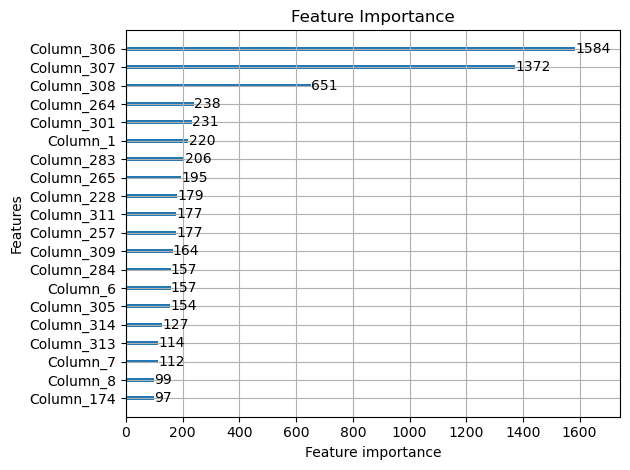

In [23]:
# Looking at feature importance.
lgb_model = lgbm_pipeline.named_steps['regressor']
lgb.plot_importance(lgb_model, max_num_features=20)
plt.title("Feature Importance")
plt.tight_layout()
plt.show()


In [24]:
def get_feature_names_legacy(column_transformer, input_features):
    output_features = []

    for name, transformer, columns in column_transformer.transformers_:
        if transformer == 'drop':
            continue

        if transformer == 'passthrough':
            # Support both list and slice-based passthrough
            if isinstance(columns, slice):
                passthrough_columns = input_features[columns]
            else:
                passthrough_columns = columns
            output_features.extend(passthrough_columns)
            continue

        # Handle pipelines or direct transformers
        if hasattr(transformer, 'get_feature_names'):
            try:
                names = transformer.get_feature_names(columns)
            except:
                names = columns
            output_features.extend(names)

        else:
            output_features.extend(columns)

    return output_features

In [27]:
# Get feature names from the preprocessor
preprocessor = lgbm_pipeline.named_steps['preprocessing']
# Get transformed feature names
feature_names = preprocessor.get_feature_names_out()

# Get feature importances from LightGBM regressor
lgb_model = lgbm_pipeline.named_steps['regressor']

# Create a DataFrame for inspection
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': lgb_model.feature_importances_
}).sort_values(by='importance', ascending=False)

print(importance_df.head(10))

                             feature  importance
306      remainder__registrationyear        1584
307                 remainder__power        1372
308               remainder__mileage         651
264               onehot__brand_audi         238
301         onehot__brand_volkswagen         231
1    onehot__vehicletype_convertible         220
283      onehot__brand_mercedes_benz         206
265                onehot__brand_bmw         195
228        onehot__model_transporter         179
311            remainder__postalcode         177


From the feature importance, it looks like 'remainder__registrationyear', 'remainder__power', and 'remainder__mileage' in our model have the largest affect on the target 'price'. I think this is in line with our common sense. Registration year and mileage probably have a large inverse relationship with the price. The fewer years and miles a car has, the more valuable it is. Power is a direct relationship; the more power a car has, the greater the value.